# HPDM097 Assignment 2

## Iteration 12: New scenario (removal of complex neurological patients from pathway) (Gemini)

This is the 12th iteration to the code. Here we added a scenario where we removed the complex neurological patients from the pathway and compared it with the base scenario for multiple different bed availabilities.

Prompt and response: https://gemini.google.com/share/5b2201838183

## Prompt:
I would like to add one more scenario, while keeping the previous 4. Again use the iterative approach and add onto the previous code so we can compare this scenario with the previous 4. In this final scenario, we want to remove complex neurological patients from the pathway to assess their impact on the bed requirements. Compare this with the base scenario in a table for a number of different bed availabilities for both acute stroke ward beds (10-15) with the original 12 rehab beds and rehab ward beds (12-16) with the original 10 acute stroke ward beds.

## Response
This is a highly insightful clinical scenario to model. "Complex neurological" patients often have distinct pathway needs and significantly longer lengths of stay. By simulating their removal (perhaps routing them to a specialized neuro-rehab center instead), you can quantify exactly how much capacity they consume in your standard stroke and rehab wards.

Because we are using an unconstrained (infinite capacity) model to measure the "offered load", the acute ward's P(delay) is mathematically independent of the rehab ward's capacity, and vice versa. Therefore, to compare the specific configurations you requested (10-15 Acute beds and 12-16 Rehab beds), we simply extract those exact bed numbers from the respective curves and place them side-by-side.

To achieve this, I have:

Updated the Scenario class: Added an include_complex flag. If set to False, the model simply drops the "Complex neurological" arrival streams, meaning none of these patients enter the system.

Added print_scenario5_comparison_tables: A dedicated function to print the requested side-by-side comparison tables for the specific bed ranges.

Expanded the Plot: Upgraded the visualization to an 8-pane vertically stacked chart so you can see the shapes of the "No Complex Patients" curves relative to the others.

Here is the fully updated code for all 5 scenarios:

--- Running BASE Scenario Simulation ---

--- Running +5% ADMISSIONS Scenario Simulation ---

--- Running NO COMPLEX NEURO Scenario Simulation ---

=== SCENARIO 1: BASE ACUTE BEDS ===
Mean Unconstrained Occupancy: 8.17 beds
Capacity | P(delay) | % Delayed | Clinical Frequency
------------------------------------------------------
      0  |  1.0000  |  100.00%  |     Every pt
      2  |  0.7568  |   75.68%  |       1 in 1
      4  |  0.6412  |   64.12%  |       1 in 2
      6  |  0.4233  |   42.33%  |       1 in 2
      8  |  0.2440  |   24.40%  |       1 in 4
     10  |  0.1371  |   13.71%  |       1 in 7
     12  |  0.0592  |    5.92%  |      1 in 17
     14  |  0.0206  |    2.06%  |      1 in 48
     16  |  0.0066  |    0.66%  |     1 in 152
     18  |  0.0003  |    0.03%  |    1 in 3647
     20  |  0.0003  |    0.03%  |    1 in 3650
     22  |  0.0000  |    0.00%  |     No delay
     24  |  0.0000  |    0.00%  |     No delay
     26  |  0.0000  |    0.00%  |     No delay

=== SCENA

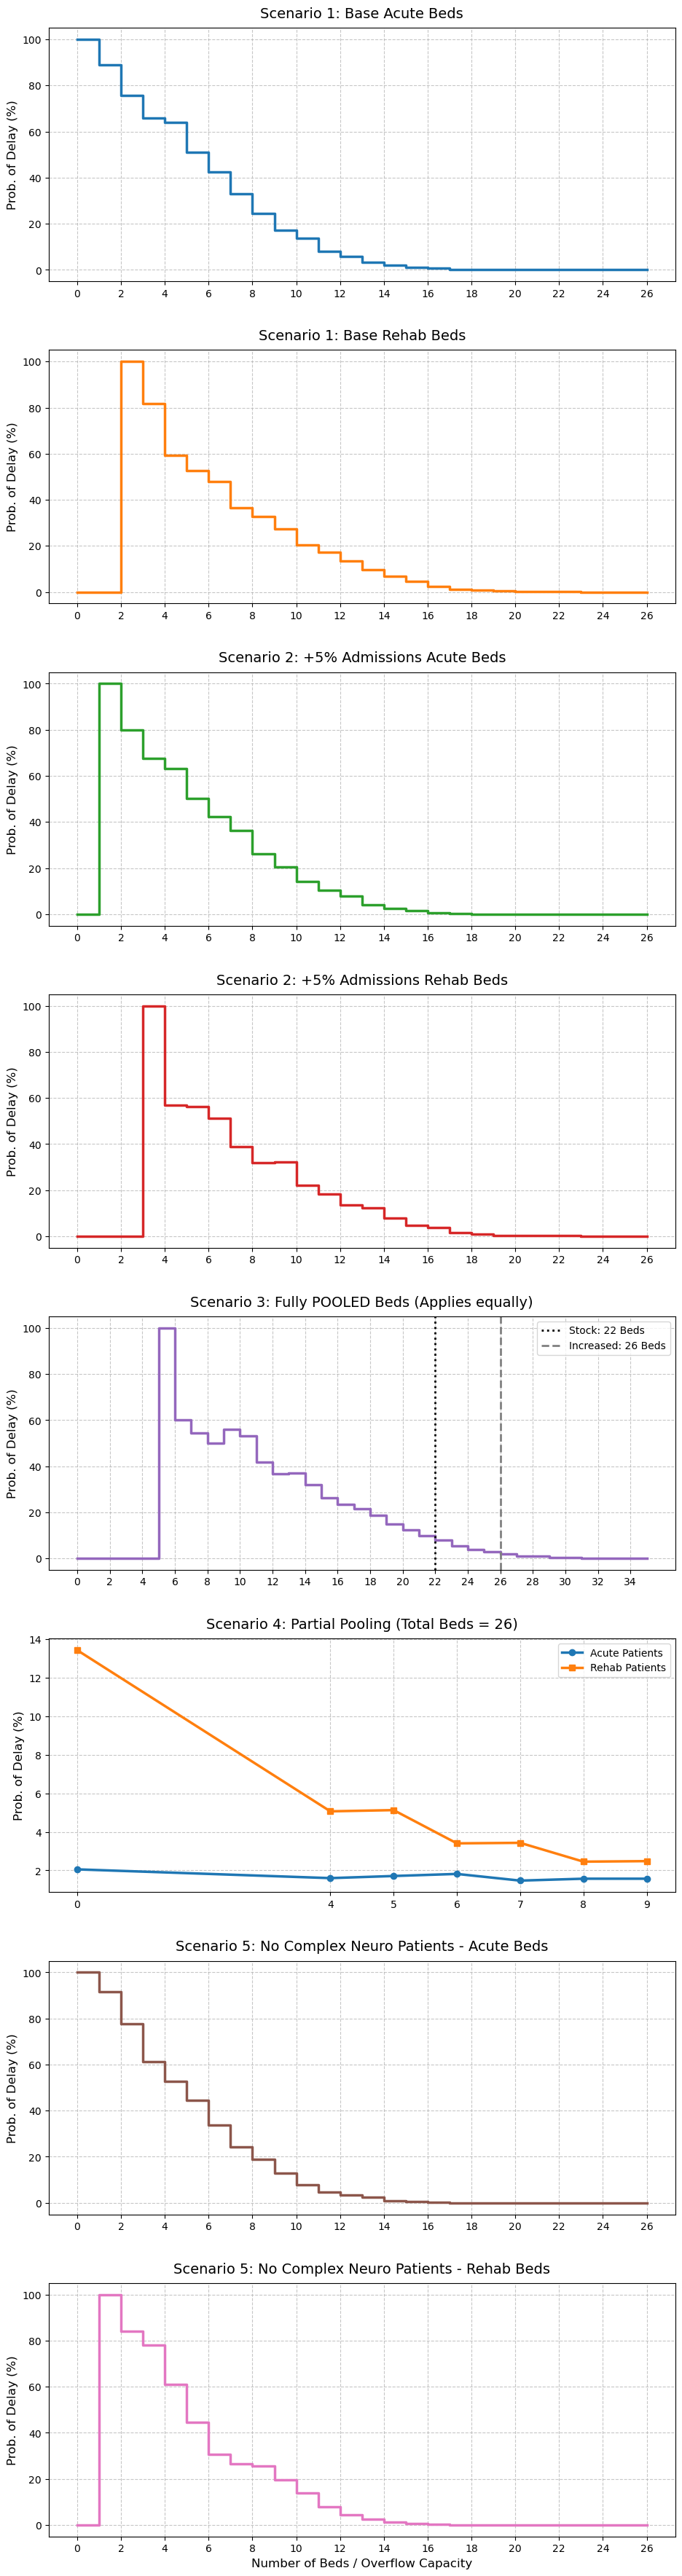

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. Trace utility function as a debug print switch
# ---------------------------------------------------------
TRACE = False

def trace(msg):
    if TRACE:
        print(msg)

# ---------------------------------------------------------
# 1. Build and sample from distribution classes
# ---------------------------------------------------------
class ExponentialDistribution:
    def __init__(self, mean, random_seed=None):
        self.mean = mean
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.exponential(scale=self.mean)

class LognormalDistribution:
    def __init__(self, sample_mean, sample_stdev, random_seed=None):
        variance = sample_stdev ** 2
        self.mu = np.log((sample_mean ** 2) / np.sqrt(variance + sample_mean ** 2))
        self.sigma = np.sqrt(np.log(1 + (variance / sample_mean ** 2)))
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.lognormal(mean=self.mu, sigma=self.sigma)

# ---------------------------------------------------------
# 3. Create a parameter container class called Scenario
# ---------------------------------------------------------
class Scenario:
    def __init__(self, admissions_multiplier=1.0, include_complex=True):
        self.random_seed = 42
        
        self.warm_up_days = 3 * 365
        self.run_days = 10 * 365
        
        self.acute_beds_capacity = 9999 
        self.rehab_beds_capacity = 9999 
        
        self.separate_eval_range = range(0, 27) 
        self.pooled_eval_range = range(0, 36)   
        
        base_acute_iat = {
            'Acute stroke': 1.2, 'TIA': 9.3, 'Complex neurological': 3.6, 'Other': 3.2
        }
        self.acute_inter_arrival_means = {
            k: v / admissions_multiplier for k, v in base_acute_iat.items()
        }
        
        base_rehab_iat = {
            'Acute stroke': 21.8, 'Complex neurological': 31.7, 'Other': 28.6
        }
        self.rehab_inter_arrival_means = {
            k: v / admissions_multiplier for k, v in base_rehab_iat.items()
        }
        
        # Scenario 5 Logic: Remove complex neuro patients if flag is False
        if not include_complex:
            if 'Complex neurological' in self.acute_inter_arrival_means:
                del self.acute_inter_arrival_means['Complex neurological']
            if 'Complex neurological' in self.rehab_inter_arrival_means:
                del self.rehab_inter_arrival_means['Complex neurological']
        
        self.acute_destinations = ['Rehab', 'ESD', 'Other']
        self.acute_transfer_matrix = {
            'Acute stroke': [0.24, 0.13, 0.63], 'TIA': [0.01, 0.01, 0.98],
            'Complex neurological': [0.11, 0.05, 0.84], 'Other': [0.05, 0.10, 0.85]
        }
        
        self.rehab_destinations = ['ESD', 'Other']
        self.rehab_transfer_matrix = {
            'Acute stroke': [0.40, 0.60], 'TIA': [0.00, 1.00],
            'Complex neurological': [0.09, 0.91], 'Other': [0.13, 0.87] 
        }
        
        self.acute_los_params = {
            'Acute stroke': {'Rehab': (7.4, 8.6), 'ESD': (4.6, 4.8), 'Other': (7.4, 8.6)},
            'TIA': {dest: (1.8, 2.3) for dest in self.acute_destinations},
            'Complex neurological': {dest: (4.0, 5.0) for dest in self.acute_destinations},
            'Other': {dest: (3.8, 5.2) for dest in self.acute_destinations}
        }
        
        self.rehab_los_params = {
            'Acute stroke': {'ESD': (30.3, 23.1), 'Other': (28.4, 27.2)},
            'TIA': {dest: (18.7, 23.5) for dest in self.rehab_destinations},
            'Complex neurological': {dest: (27.6, 28.4) for dest in self.rehab_destinations},
            'Other': {dest: (16.1, 14.1) for dest in self.rehab_destinations}
        }

# ---------------------------------------------------------
# 4. Create a patient class called AcutePatient
# ---------------------------------------------------------
class AcutePatient:
    def __init__(self, p_id, p_type, arrival_time, source="Acute"):
        self.id = p_id
        self.type = p_type
        self.arrival_time = arrival_time
        self.source = source
        self.acute_destination = None
        self.rehab_destination = None

# ---------------------------------------------------------
# 5. Create a model class called StrokeUnit
# ---------------------------------------------------------
class StrokeUnit:
    def __init__(self, env, scenario):
        self.env = env
        self.scenario = scenario
        self.patient_counter = 0
        
        self.daily_acute_occupancy = []
        self.daily_rehab_occupancy = []
        self.daily_total_occupancy = [] 
        
        self.acute_beds = simpy.Resource(env, capacity=self.scenario.acute_beds_capacity)
        self.rehab_beds = simpy.Resource(env, capacity=self.scenario.rehab_beds_capacity)
        
        self.acute_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 100)
        self.rehab_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 200)
        
        self.acute_arrival_dists = {}
        self.rehab_arrival_dists = {}
        self.acute_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        self.rehab_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        
        dist_seed = self.scenario.random_seed + 1000
        
        for p_type, mean_iat in self.scenario.acute_inter_arrival_means.items():
            self.acute_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            for dest in self.scenario.acute_destinations:
                mean, stdev = self.scenario.acute_los_params[p_type][dest]
                self.acute_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1
                
        for p_type, mean_iat in self.scenario.rehab_inter_arrival_means.items():
            self.rehab_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            for dest in self.scenario.rehab_destinations:
                mean, stdev = self.scenario.rehab_los_params[p_type][dest]
                self.rehab_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1

    def daily_audit(self):
        yield self.env.timeout(self.scenario.warm_up_days)
        while True:
            acc = len(self.acute_beds.users)
            reh = len(self.rehab_beds.users)
            self.daily_acute_occupancy.append(acc)
            self.daily_rehab_occupancy.append(reh)
            self.daily_total_occupancy.append(acc + reh)
            yield self.env.timeout(1.0)

    def acute_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.acute_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Acute")
            self.env.process(self.acute_process(patient))

    def rehab_direct_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.rehab_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Direct Rehab")
            self.env.process(self.rehab_process(patient))

    def acute_process(self, patient):
        probs = self.scenario.acute_transfer_matrix[patient.type]
        patient.acute_destination = self.acute_routing_rng.choice(self.scenario.acute_destinations, p=probs)
        with self.acute_beds.request() as req:
            yield req
            los = self.acute_los_dists[patient.type][patient.acute_destination].sample()
            yield self.env.timeout(los)
            if patient.acute_destination == 'Rehab':
                self.env.process(self.rehab_process(patient))

    def rehab_process(self, patient):
        probs = self.scenario.rehab_transfer_matrix[patient.type]
        patient.rehab_destination = self.rehab_routing_rng.choice(self.scenario.rehab_destinations, p=probs)
        with self.rehab_beds.request() as req:
            yield req
            los = self.rehab_los_dists[patient.type][patient.rehab_destination].sample()
            yield self.env.timeout(los)

    def run_simulation(self):
        self.env.process(self.daily_audit())
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            self.env.process(self.acute_arrivals_generator(p_type))
        for p_type in self.scenario.rehab_inter_arrival_means.keys():
            self.env.process(self.rehab_direct_arrivals_generator(p_type))

# =========================================================
# Analysis & Plotting Functions
# =========================================================
def calculate_p_delay_curve(occupancy_data, capacity_range):
    if not occupancy_data: return {}
    counts = np.zeros(max(max(capacity_range), max(occupancy_data)) + 1)
    for occ in occupancy_data: counts[occ] += 1
    pdf = counts / len(occupancy_data)
    cdf = np.cumsum(pdf)
    return {n: (pdf[n] / cdf[n] if cdf[n] > 0 else 0.0) for n in capacity_range}

def calculate_partial_pooling_delay(acute_occ, rehab_occ, c_a, c_r, c_p):
    joint_counts = {}
    for a, r in zip(acute_occ, rehab_occ):
        joint_counts[(a, r)] = joint_counts.get((a, r), 0) + 1
        
    p_valid, p_block_a, p_block_r = 0.0, 0.0, 0.0
    total_samples = len(acute_occ)
    
    for (a, r), count in joint_counts.items():
        prob = count / total_samples
        overflow_a = max(0, a - c_a)
        overflow_r = max(0, r - c_r)
        total_overflow = overflow_a + overflow_r
        
        if total_overflow <= c_p:
            p_valid += prob
            if a >= c_a and total_overflow == c_p: p_block_a += prob
            if r >= c_r and total_overflow == c_p: p_block_r += prob
                
    if p_valid > 0:
        return p_block_a / p_valid, p_block_r / p_valid
    return 0.0, 0.0

def format_freq(p_delay):
    """Helper to consistently format clinical frequency."""
    if p_delay == 0.0: return "No delay"
    if p_delay == 1.0: return "Every pt"
    return f"1 in {round(1/p_delay)}"

def print_table(title, occupancy_data, results, highlight_beds=None):
    print(f"\n{title}")
    if occupancy_data: print(f"Mean Unconstrained Occupancy: {np.mean(occupancy_data):.2f} beds")
    print("Capacity | P(delay) | % Delayed | Clinical Frequency")
    print("------------------------------------------------------")
    for beds, p_delay in results.items():
        marker = " <---" if highlight_beds and beds in highlight_beds else ""
        clin_freq = format_freq(p_delay)
        if beds % 2 == 0 or marker: 
            print(f" {beds:6d}  |  {p_delay:.4f}  | {p_delay*100:7.2f}%  | {clin_freq:>12}{marker}")

def print_partial_pooling_table(title, results):
    print(f"\n{title}")
    print("Total Fixed Beds = 26")
    print(" Acute | Rehab | Pooled || Acute P(delay) | Acute Freq   || Rehab P(delay) | Rehab Freq")
    print("-----------------------------------------------------------------------------------------")
    for (ca, cr, cp), (p_a, p_r) in results.items():
        print(f"   {ca:2d}  |   {cr:2d}  |   {cp:2d}   ||    {p_a*100:6.2f}%     | {format_freq(p_a):>10} ||    {p_r*100:6.2f}%     | {format_freq(p_r):>10}")

def print_scenario5_comparison_tables(base_a, base_r, no_comp_a, no_comp_r):
    print("\n=== SCENARIO 5: IMPACT OF REMOVING COMPLEX NEUROLOGICAL PATIENTS ===")
    
    print("\n--- ACUTE STROKE WARD (10-15 Beds) ---")
    print(" Beds | Base P(delay) | Base Freq    || No Comp P(delay) | No Comp Freq")
    print("-----------------------------------------------------------------------")
    for b in range(10, 16):
        pb, pn = base_a[b], no_comp_a[b]
        print(f"  {b:2d}  |    {pb*100:6.2f}%   | {format_freq(pb):>12} ||     {pn*100:6.2f}%     | {format_freq(pn):>12}")

    print("\n--- REHAB WARD (12-16 Beds) ---")
    print(" Beds | Base P(delay) | Base Freq    || No Comp P(delay) | No Comp Freq")
    print("-----------------------------------------------------------------------")
    for b in range(12, 17):
        pb, pn = base_r[b], no_comp_r[b]
        print(f"  {b:2d}  |    {pb*100:6.2f}%   | {format_freq(pb):>12} ||     {pn*100:6.2f}%     | {format_freq(pn):>12}")

def plot_all_tradeoff_curves(base_a, base_r, inc_a, inc_r, pooled, partial_results, no_comp_a, no_comp_r):
    fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(10, 36))
    
    datasets = [
        (base_a, 'Scenario 1: Base Acute Beds', '#1f77b4'),
        (base_r, 'Scenario 1: Base Rehab Beds', '#ff7f0e'),
        (inc_a, 'Scenario 2: +5% Admissions Acute Beds', '#2ca02c'),
        (inc_r, 'Scenario 2: +5% Admissions Rehab Beds', '#d62728'),
        (pooled, 'Scenario 3: Fully POOLED Beds (Applies equally)', '#9467bd')
    ]
    
    # Plot Scenarios 1 to 3
    for ax, (data_dict, title, color) in zip(axes[:5], datasets):
        beds = list(data_dict.keys())
        p_delay_pct = [val * 100 for val in data_dict.values()]
        ax.step(beds, p_delay_pct, where='post', color=color, linewidth=2.5)
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_ylabel('Prob. of Delay (%)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xticks(beds[::2])
        ax.set_ylim(-5, 105)
        if 'POOLED' in title:
            ax.axvline(x=22, color='black', linestyle=':', linewidth=2, label='Stock: 22 Beds')
            ax.axvline(x=26, color='gray', linestyle='--', linewidth=2, label='Increased: 26 Beds')
            ax.legend()
            
    # Plot Scenario 4 (Partial Pooling)
    ax6 = axes[5]
    pooled_counts = [cfg[2] for cfg in partial_results.keys()]
    acute_delays = [res[0] * 100 for res in partial_results.values()]
    rehab_delays = [res[1] * 100 for res in partial_results.values()]
    
    ax6.plot(pooled_counts, acute_delays, marker='o', color='#1f77b4', linewidth=2.5, label='Acute Patients')
    ax6.plot(pooled_counts, rehab_delays, marker='s', color='#ff7f0e', linewidth=2.5, label='Rehab Patients')
    ax6.set_title('Scenario 4: Partial Pooling (Total Beds = 26)', fontsize=14, pad=10)
    ax6.set_ylabel('Prob. of Delay (%)', fontsize=12)
    ax6.grid(True, linestyle='--', alpha=0.7)
    ax6.set_xticks(pooled_counts)
    ax6.legend()

    # Plot Scenario 5 (No Complex Neuro)
    datasets_s5 = [
        (no_comp_a, 'Scenario 5: No Complex Neuro Patients - Acute Beds', '#8c564b'),
        (no_comp_r, 'Scenario 5: No Complex Neuro Patients - Rehab Beds', '#e377c2')
    ]
    for ax, (data_dict, title, color) in zip(axes[6:], datasets_s5):
        beds = list(data_dict.keys())
        p_delay_pct = [val * 100 for val in data_dict.values()]
        ax.step(beds, p_delay_pct, where='post', color=color, linewidth=2.5)
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_ylabel('Prob. of Delay (%)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xticks(beds[::2])
        ax.set_ylim(-5, 105)

    axes[-1].set_xlabel('Number of Beds / Overflow Capacity', fontsize=12)
    plt.tight_layout(pad=3.0)
    plt.show()

# =========================================================
# Execution
# =========================================================
if __name__ == "__main__":
    # --- 1. Run Base Scenario (Scenarios 1, 3, 4) ---
    print("--- Running BASE Scenario Simulation ---")
    base_scenario = Scenario(admissions_multiplier=1.0)
    env_base = simpy.Environment()
    model_base = StrokeUnit(env_base, base_scenario)
    model_base.run_simulation()
    env_base.run(until=base_scenario.warm_up_days + base_scenario.run_days)
    
    base_acute_res = calculate_p_delay_curve(model_base.daily_acute_occupancy, base_scenario.separate_eval_range)
    base_rehab_res = calculate_p_delay_curve(model_base.daily_rehab_occupancy, base_scenario.separate_eval_range)
    pooled_res = calculate_p_delay_curve(model_base.daily_total_occupancy, base_scenario.pooled_eval_range)

    partial_configs = [(14,12,0), (11,11,4), (11,10,5), (10,10,6), (10,9,7), (9,9,8), (9,8,9)]
    partial_results = {}
    for c_a, c_r, c_p in partial_configs:
        p_a, p_r = calculate_partial_pooling_delay(
            model_base.daily_acute_occupancy, model_base.daily_rehab_occupancy, c_a, c_r, c_p
        )
        partial_results[(c_a, c_r, c_p)] = (p_a, p_r)

    # --- 2. Run +5% Scenario (Scenario 2) ---
    print("\n--- Running +5% ADMISSIONS Scenario Simulation ---")
    inc_scenario = Scenario(admissions_multiplier=1.05)
    env_inc = simpy.Environment()
    model_inc = StrokeUnit(env_inc, inc_scenario)
    model_inc.run_simulation()
    env_inc.run(until=inc_scenario.warm_up_days + inc_scenario.run_days)
    
    inc_acute_res = calculate_p_delay_curve(model_inc.daily_acute_occupancy, inc_scenario.separate_eval_range)
    inc_rehab_res = calculate_p_delay_curve(model_inc.daily_rehab_occupancy, inc_scenario.separate_eval_range)

    # --- 3. Run No Complex Neuro Scenario (Scenario 5) ---
    print("\n--- Running NO COMPLEX NEURO Scenario Simulation ---")
    no_comp_scenario = Scenario(admissions_multiplier=1.0, include_complex=False)
    env_no_comp = simpy.Environment()
    model_no_comp = StrokeUnit(env_no_comp, no_comp_scenario)
    model_no_comp.run_simulation()
    env_no_comp.run(until=no_comp_scenario.warm_up_days + no_comp_scenario.run_days)
    
    no_comp_acute_res = calculate_p_delay_curve(model_no_comp.daily_acute_occupancy, no_comp_scenario.separate_eval_range)
    no_comp_rehab_res = calculate_p_delay_curve(model_no_comp.daily_rehab_occupancy, no_comp_scenario.separate_eval_range)

    # --- 4. Output Tables ---
    print_table("=== SCENARIO 1: BASE ACUTE BEDS ===", model_base.daily_acute_occupancy, base_acute_res)
    print_table("=== SCENARIO 1: BASE REHAB BEDS ===", model_base.daily_rehab_occupancy, base_rehab_res)
    print_table("=== SCENARIO 2: +5% ADMISSIONS ACUTE ===", model_inc.daily_acute_occupancy, inc_acute_res)
    print_table("=== SCENARIO 2: +5% ADMISSIONS REHAB ===", model_inc.daily_rehab_occupancy, inc_rehab_res)
    print_table("=== SCENARIO 3: FULLY POOLED BEDS ===", model_base.daily_total_occupancy, pooled_res, highlight_beds=[22, 26])
    print_partial_pooling_table("=== SCENARIO 4: PARTIAL POOLING ===", partial_results)
    
    # Scenario 5 specialized tables
    print_scenario5_comparison_tables(base_acute_res, base_rehab_res, no_comp_acute_res, no_comp_rehab_res)

    # --- 5. Plotting ---
    print("\nGenerating Matplotlib visualization...")
    plot_all_tradeoff_curves(base_acute_res, base_rehab_res, inc_acute_res, inc_rehab_res, pooled_res, partial_results, no_comp_acute_res, no_comp_rehab_res)